In [20]:
import os
import sys
from pathlib import Path

print("Current directory:", os.getcwd())

# If notebook is running inside app/, move to the project root
current_path = Path.cwd()

if current_path.name == "app":
    project_root = current_path.parent
else:
    project_root = current_path

# Add project root to Python's import path
sys.path.insert(0, str(project_root))

print("Project root:", project_root)
print("Project root exists:", project_root.exists())

Current directory: c:\Users\91920\OneDrive\Desktop\triageAgent\app
Project root: c:\Users\91920\OneDrive\Desktop\triageAgent
Project root exists: True


In [21]:
from langchain_groq import ChatGroq
from langgraph.graph import StateGraph, START, END

from app.state import TriageState, TriageResult, ValidationResult
from app.persistence import save_triage_result

from dotenv import load_dotenv
import os

In [3]:
load_dotenv()

GROQ_API_KEY = os.getenv("GROQ_API_KEY")
GROQ_MODEL = os.getenv("GROQ_MODEL")

model = ChatGroq(
    model=GROQ_MODEL,
    api_key=GROQ_API_KEY,
    temperature=0,
)

structured_model = model.with_structured_output(
    TriageResult
)

In [4]:
def classify_with_llm(state: TriageState):
    subject = state.get("subject", "").strip()
    email = state.get("email", "").strip()

    if not email:
        raise ValueError("Email body cannot be empty.")

    prompt = f"""
You are an email triage system.

Classify the following email.

Email Subject:
{subject}

Email Body:
{email}

Follow these rules:
1. Classify the email into one of:
   Complaint, Feedback, Request, Spam, Other

2. Assign a priority:
   Low, Medium, High, Critical

3. Generate a short and accurate summary.

4. Provide a confidence score between 0 and 1.

5. Set needs_human_review to true if:
   - The email involves a security incident.
   - The email involves a legal or financial risk.
   - The email requires urgent attention.
   - You are uncertain about the classification.

Return the result according to the required structured format.
"""

    result = structured_model.invoke(prompt)

    return {
        "triage_result": result
    }

In [5]:

def validate_triage(state: TriageState):
    triage_result = state.get("triage_result")

    if triage_result is None:
        return {
            "validation_result": ValidationResult(
                passed=False,
                errors=["Triage result is missing."],
                review_reason="The LLM did not return a triage result.",
                route="human_review",
            )
        }

    errors = []

    # Rule 1: Low confidence
    if triage_result.confidence < 0.70:
        errors.append(
            "LLM confidence is below the required threshold."
        )

    # Rule 2: Critical priority
    if triage_result.priority == "Critical":
        errors.append(
            "Critical-priority email requires human review."
        )

    # Rule 3: High priority
    if triage_result.priority == "High":
        errors.append(
            "High-priority email requires human review."
        )

    # Rule 4: LLM explicitly requests review
    if triage_result.needs_human_review:
        errors.append(
            "LLM requested human review."
        )

    # Rule: Spam gets a dedicated route
    if triage_result.category == "Spam":
        return {
            "validation_result": ValidationResult(
                passed=True,
                errors=[],
                review_reason="",
                route="spam",
            )
        }

    if errors:
        return {
            "validation_result": ValidationResult(
                passed=False,
                errors=errors,
                review_reason="; ".join(errors),
                route="human_review",
            )
        }

    return {
        "validation_result": ValidationResult(
            passed=True,
            errors=[],
            review_reason="",
            route="automatic_processing",
        )
    }

In [6]:
def spam_handling(state: TriageState):
    triage_result = state.get("triage_result")

    print("\n--- SPAM HANDLING ---")

    if triage_result:
        print("Category:", triage_result.category)
        print("Priority:", triage_result.priority)
        print("Summary:", triage_result.summary)

    print("Action: Email marked as spam.")
    print("Action: No ticket will be created.")

    return {}

In [7]:
def route_email(state: TriageState):
    validation_result = state.get("validation_result")

    if validation_result is None:
        return "human_review"

    return validation_result.route

In [8]:
def human_review(state: TriageState):
    triage_result = state.get("triage_result")
    validation_result = state.get("validation_result")

    print("\n--- HUMAN REVIEW REQUIRED ---")

    if triage_result:
        print("Category:", triage_result.category)
        print("Priority:", triage_result.priority)
        print("Summary:", triage_result.summary)

    if validation_result:
        print("Validation Errors:", validation_result.errors)
        print("Review Reason:", validation_result.review_reason)

    return {}

In [9]:
def automatic_processing(state: TriageState):
    triage_result = state.get("triage_result")

    print("\n--- AUTOMATIC PROCESSING ---")

    if triage_result:
        print("Category:", triage_result.category)
        print("Priority:", triage_result.priority)
        print("Summary:", triage_result.summary)

    return {}

In [10]:

from app.persistence import save_triage_result


def save_to_database(state: TriageState):
    email = state.get("email", "")
    triage_result = state.get("triage_result")
    validation_result = state.get("validation_result")

    if not triage_result or not validation_result:
        raise ValueError(
            "Triage or validation result is missing."
        )

    email_id = save_triage_result(
        message_id=f"local-{abs(hash(email))}",
        subject="Test Email",
        body=email,
        triage_result=triage_result,
        validation_result=validation_result,
    )

    print("Saved Email ID:", email_id)

    return {}

In [11]:
def route_email(state: TriageState):
    validation_result = state.get("validation_result")

    if validation_result is None:
        return "human_review"

    return validation_result.route

In [12]:
builder = StateGraph(TriageState)

builder.add_node("classify_with_llm", classify_with_llm)
builder.add_node("validate_triage", validate_triage)
builder.add_node("human_review", human_review)
builder.add_node("automatic_processing", automatic_processing)
builder.add_node("spam_handling", spam_handling)
builder.add_node("save_to_database", save_to_database)

builder.add_edge(START, "classify_with_llm")
builder.add_edge("classify_with_llm", "validate_triage")

builder.add_conditional_edges(
    "validate_triage",
    route_email,
    {
        "human_review": "human_review",
        "automatic_processing": "automatic_processing",
        "spam": "spam_handling",
    },
)

builder.add_edge("human_review", "save_to_database")
builder.add_edge("automatic_processing", "save_to_database")
builder.add_edge("spam_handling", "save_to_database")
builder.add_edge("save_to_database", END)

graph = builder.compile()



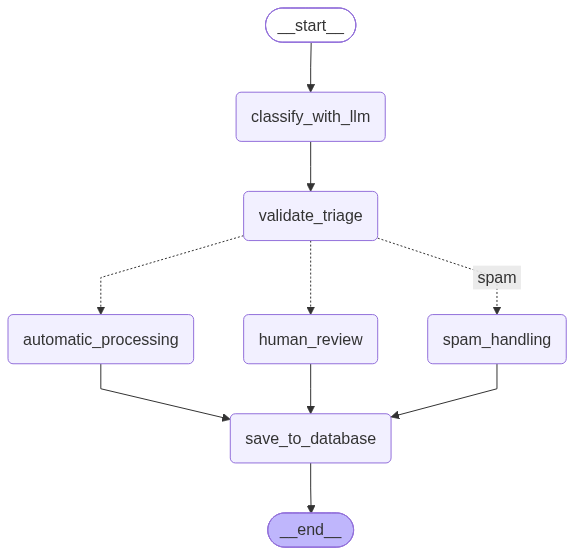

In [13]:
from IPython.display import display, Image


Image(graph.get_graph().draw_mermaid_png())



In [14]:
result = graph.invoke({
    "subject": "Congratulations! You won a prize",
    "email": """
    You have won a guaranteed cash prize.
    Click this link immediately to claim your reward.
    """
})

print(result)


--- SPAM HANDLING ---
Category: Spam
Priority: Low
Summary: Congratulations! You won a prize
Action: Email marked as spam.
Action: No ticket will be created.
Email and triage result saved successfully.
Saved Email ID: 587dbb73-67ab-45ff-ba30-b11b7205837b
{'subject': 'Congratulations! You won a prize', 'email': '\n    You have won a guaranteed cash prize.\n    Click this link immediately to claim your reward.\n    ', 'triage_result': TriageResult(category='Spam', priority='Low', summary='Congratulations! You won a prize', confidence=0.98, needs_human_review=False), 'validation_result': ValidationResult(passed=True, errors=[], review_reason='', route='spam')}


In [16]:
result = graph.invoke({
    "subject": "Urgent: My account was charged twice",
    "email": """
    I was charged twice for the same transaction.
    Please investigate this immediately and refund the extra amount.
    """
})

print(result)


--- HUMAN REVIEW REQUIRED ---
Category: Complaint
Priority: High
Summary: Customer reports being charged twice for the same transaction and requests an immediate investigation and refund of the extra amount.
Validation Errors: ['High-priority email requires human review.', 'LLM requested human review.']
Review Reason: High-priority email requires human review.; LLM requested human review.
Email and triage result saved successfully.
Saved Email ID: d0044581-a734-488f-bdae-028033436b48
{'subject': 'Urgent: My account was charged twice', 'email': '\n    I was charged twice for the same transaction.\n    Please investigate this immediately and refund the extra amount.\n    ', 'triage_result': TriageResult(category='Complaint', priority='High', summary='Customer reports being charged twice for the same transaction and requests an immediate investigation and refund of the extra amount.', confidence=0.95, needs_human_review=True), 'validation_result': ValidationResult(passed=False, errors=['

In [17]:
result = graph.invoke({
    "subject": "Issue",
    "email": """
    Something happened with my account.
    I am not sure what went wrong.
    Please help.
    """
})

print(result)


--- HUMAN REVIEW REQUIRED ---
Category: Request
Priority: Medium
Summary: User reports an unknown issue with their account and requests assistance to resolve it.
Validation Errors: ['LLM requested human review.']
Review Reason: LLM requested human review.
Email and triage result saved successfully.
Saved Email ID: 6b43a33f-22aa-4dd0-b3ce-8a6324311edd
{'subject': 'Issue', 'email': '\n    Something happened with my account.\n    I am not sure what went wrong.\n    Please help.\n    ', 'triage_result': TriageResult(category='Request', priority='Medium', summary='User reports an unknown issue with their account and requests assistance to resolve it.', confidence=0.75, needs_human_review=True), 'validation_result': ValidationResult(passed=False, errors=['LLM requested human review.'], review_reason='LLM requested human review.', route='human_review')}


In [18]:
from app.state import TriageResult


test_state = {
    "subject": "Unclear issue",
    "email": "I have a problem but I cannot explain it.",
    "triage_result": TriageResult(
        category="Request",
        priority="Medium",
        summary="User reports an unclear issue.",
        confidence=0.40,
        needs_human_review=False,
    ),
}

validation_output = validate_triage(test_state)

print(validation_output)

{'validation_result': ValidationResult(passed=False, errors=['LLM confidence is below the required threshold.'], review_reason='LLM confidence is below the required threshold.', route='human_review')}


In [19]:
from app.state import TriageResult
from pprint import pprint


def test_validation_case(name, triage_result):
    test_state = {
        "subject": "Test email",
        "email": "This is a test email.",
        "triage_result": triage_result,
    }

    result = validate_triage(test_state)

    print(f"\n--- {name} ---")
    pprint(result)


# Case 1: Normal email
test_validation_case(
    "Normal email",
    TriageResult(
        category="Feedback",
        priority="Low",
        summary="User provides positive feedback.",
        confidence=0.95,
        needs_human_review=False,
    ),
)


# Case 2: Low confidence
test_validation_case(
    "Low confidence",
    TriageResult(
        category="Request",
        priority="Medium",
        summary="User has an unclear request.",
        confidence=0.40,
        needs_human_review=False,
    ),
)


# Case 3: High priority
test_validation_case(
    "High priority",
    TriageResult(
        category="Complaint",
        priority="High",
        summary="User reports a serious issue.",
        confidence=0.95,
        needs_human_review=False,
    ),
)


# Case 4: Spam
test_validation_case(
    "Spam",
    TriageResult(
        category="Spam",
        priority="Low",
        summary="Suspicious promotional email.",
        confidence=0.95,
        needs_human_review=False,
    ),
)


# Case 5: Explicit human review request
test_validation_case(
    "LLM requests human review",
    TriageResult(
        category="Request",
        priority="Medium",
        summary="User needs assistance.",
        confidence=0.95,
        needs_human_review=True,
    ),
)


--- Normal email ---
{'validation_result': ValidationResult(passed=True, errors=[], review_reason='', route='automatic_processing')}

--- Low confidence ---
{'validation_result': ValidationResult(passed=False, errors=['LLM confidence is below the required threshold.'], review_reason='LLM confidence is below the required threshold.', route='human_review')}

--- High priority ---
{'validation_result': ValidationResult(passed=False, errors=['High-priority email requires human review.'], review_reason='High-priority email requires human review.', route='human_review')}

--- Spam ---
{'validation_result': ValidationResult(passed=True, errors=[], review_reason='', route='spam')}

--- LLM requests human review ---
{'validation_result': ValidationResult(passed=False, errors=['LLM requested human review.'], review_reason='LLM requested human review.', route='human_review')}
